In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


df1 = pd.read_csv('/Volumes/lab-windingm-1/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/wiii8/interaction_type_bout.csv')
df1['condition'] = 'wiii8'


df2 = pd.read_csv('/Volumes/lab-windingm-1/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/anosmic/interaction_type_bout.csv')
df2['condition'] = 'anosmic'


df3 = pd.read_csv('/Volumes/lab-windingm-1/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/9047/interaction_type_bout.csv')
df3['condition'] = '9047'

df4 = pd.read_csv('/Volumes/lab-windingm-1/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/23129/interaction_type_bout.csv')
df4['condition'] = '23129'

df5 = pd.read_csv('/Volumes/lab-windingm-1/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/33300/interaction_type_bout.csv')
df5['condition'] = '33300'

df = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)



condition_order = ['wiii8', 'anosmic', '9047', '23129', '33300']


condition_colors = {
    'wiii8': '#385491',
    'anosmic': '#be0f0a',
    '9047': '#e7533a',
    '23129': '#fc8c59',
    '33300': "#fead61",
}



      comparison    U        p significance
anosmic vs wiii8  1.0 0.000243          ***
   9047 vs wiii8  9.5 0.002488           **
  23129 vs wiii8 14.5 0.008032           **
  33300 vs wiii8  3.0 0.000437          ***


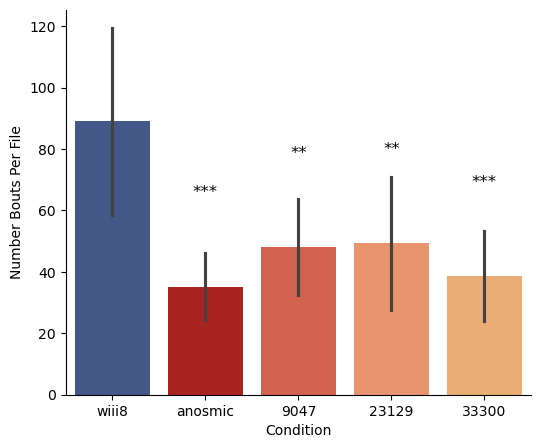

In [48]:
from scipy.stats import mannwhitneyu

bout_counts = (
    df.groupby(['condition', 'file'], as_index=False)
      .size()
      .rename(columns={'size': 'n_bouts'})
)

control = bout_counts.loc[bout_counts['condition'] == 'wiii8', 'n_bouts']
stats_rows = []

for condition in condition_order:
    if condition == 'wiii8':
        continue

    test_group = bout_counts.loc[bout_counts['condition'] == condition, 'n_bouts']
    u_stat, p_value = mannwhitneyu(test_group, control, alternative='two-sided')

    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns'

    stats_rows.append({
        'comparison': f'{condition} vs wiii8',
        'U': u_stat,
        'p': p_value,
        'significance': significance,
    })

stats_table = pd.DataFrame(stats_rows)
print(stats_table.to_string(index=False))

plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=bout_counts,
    x='condition',
    y='n_bouts',
    order=condition_order,
    hue='condition',
    hue_order=condition_order,
    palette=condition_colors,
    errorbar='sd',
    legend=False,
)

y_offset = bout_counts['n_bouts'].max() * 0.2
for row in stats_rows:
    condition = row['comparison'].split(' vs ')[0]
    x = condition_order.index(condition)
    y = bout_counts.loc[bout_counts['condition'] == condition, 'n_bouts'].mean() + y_offset
    ax.text(x, y, row['significance'], ha='center', va='bottom', fontsize=12)

plt.ylim(0, None)
plt.ylabel('Number Bouts Per File')
plt.xlabel('Condition')
sns.despine()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/sensory-mutants/interaction_bouts_count.pdf', format='pdf')
plt.show()

      comparison    U        p significance
anosmic vs wiii8 32.0 0.185877           ns
   9047 vs wiii8 90.0 0.002827           **
  23129 vs wiii8 25.0 0.064022           ns
  33300 vs wiii8 70.0 0.140465           ns


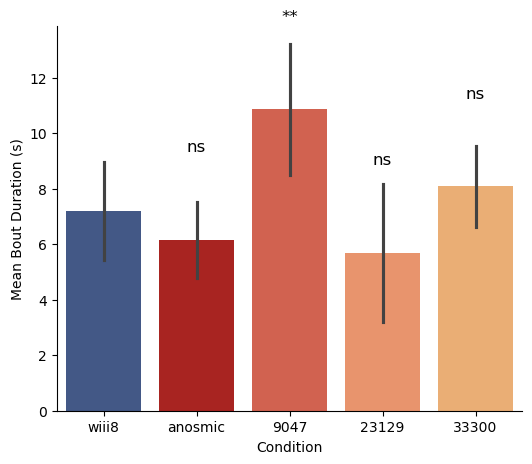

In [49]:
from scipy.stats import mannwhitneyu

duration_per_file = (
    df.groupby(['condition', 'file'], as_index=False)['duration']
      .mean()
      .rename(columns={'duration': 'mean_bout_duration'})
)

control = duration_per_file.loc[duration_per_file['condition'] == 'wiii8', 'mean_bout_duration']
stats_rows = []

for condition in condition_order:
    if condition == 'wiii8':
        continue

    test_group = duration_per_file.loc[duration_per_file['condition'] == condition, 'mean_bout_duration']
    u_stat, p_value = mannwhitneyu(test_group, control, alternative='two-sided')

    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns'

    stats_rows.append({
        'comparison': f'{condition} vs wiii8',
        'U': u_stat,
        'p': p_value,
        'significance': significance,
    })

stats_table = pd.DataFrame(stats_rows)
print(stats_table.to_string(index=False))


plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=duration_per_file,
    x='condition',
    y='mean_bout_duration',
    order=condition_order,
    hue='condition',
    hue_order=condition_order,
    palette=condition_colors,
    errorbar='sd',
    legend=False,
)

y_offset = duration_per_file['mean_bout_duration'].max() * 0.2
for row in stats_rows:
    condition = row['comparison'].split(' vs ')[0]
    x = condition_order.index(condition)
    y = duration_per_file.loc[duration_per_file['condition'] == condition, 'mean_bout_duration'].mean() + y_offset
    ax.text(x, y, row['significance'], ha='center', va='bottom', fontsize=12)

plt.ylim(0, None)
plt.ylabel('Mean Bout Duration (s)')
plt.xlabel('Condition')
sns.despine()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/sensory-mutants/interaction_bouts_duration.pdf', format='pdf')
plt.show()

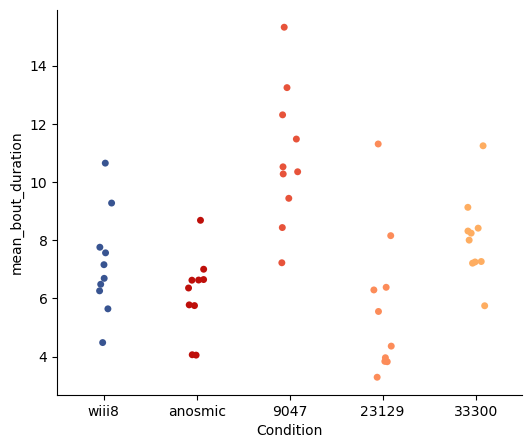

In [50]:
from scipy.stats import mannwhitneyu

duration_per_file = (
    df.groupby(['condition', 'file'], as_index=False)['duration']
      .mean()
      .rename(columns={'duration': 'mean_bout_duration'})
)

control = duration_per_file.loc[duration_per_file['condition'] == 'wiii8', 'mean_bout_duration']



plt.figure(figsize=(6,5))

sns.stripplot(
    data=duration_per_file,
    x='condition',
    y='mean_bout_duration',
    order=condition_order,
    hue='condition',
    hue_order=condition_order,
    palette=condition_colors,

)

plt.xlabel('Condition')
sns.despine()
plt.show()

initial_type       comparison    U        p significance
   head_tail anosmic vs wiii8  2.0 0.000326          ***
   head_tail    9047 vs wiii8  9.5 0.002460           **
   head_tail   23129 vs wiii8 12.0 0.004495           **
   head_tail   33300 vs wiii8  5.5 0.000865          ***
   head_head anosmic vs wiii8  5.0 0.000751          ***
   head_head    9047 vs wiii8 16.5 0.012545            *
   head_head   23129 vs wiii8 20.0 0.025692            *
   head_head   33300 vs wiii8  9.0 0.002185           **
   body_head anosmic vs wiii8  9.0 0.002135           **
   body_head    9047 vs wiii8  6.0 0.000990          ***
   body_head   23129 vs wiii8 21.0 0.030199            *
   body_head   33300 vs wiii8  1.5 0.000262          ***
   body_tail anosmic vs wiii8 58.5 0.502357           ns
   body_tail    9047 vs wiii8 63.0 0.296593           ns
   body_tail   23129 vs wiii8 60.0 0.431403           ns
   body_tail   33300 vs wiii8 34.5 0.133614           ns
   tail_tail anosmic vs wiii8 4

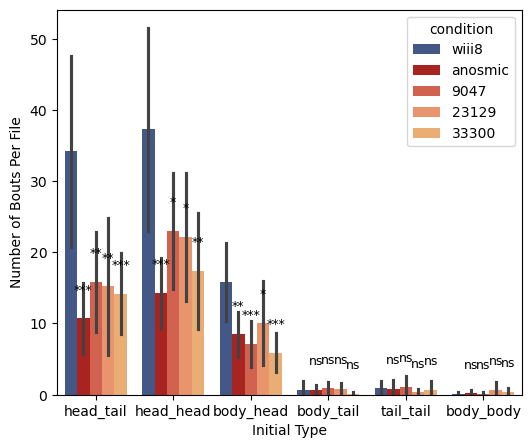

In [51]:
from scipy.stats import mannwhitneyu

counts = (
    df.groupby(['condition', 'file', 'initial_type'], as_index=False)
      .size()
      .rename(columns={'size': 'count'})
)

files = df[['condition', 'file']].drop_duplicates()
initial_types = df[['initial_type']].drop_duplicates()
counts = (
    files.merge(initial_types, how='cross')
    .merge(counts, on=['condition', 'file', 'initial_type'], how='left')
)
counts['count'] = counts['count'].fillna(0)
initial_type_order = initial_types['initial_type'].tolist()

stats_rows = []

for initial_type in initial_type_order:
    control = counts.loc[
        (counts['condition'] == 'wiii8') &
        (counts['initial_type'] == initial_type),
        'count'
    ]

    for condition in condition_order:
        if condition == 'wiii8':
            continue

        test_group = counts.loc[
            (counts['condition'] == condition) &
            (counts['initial_type'] == initial_type),
            'count'
        ]

        u_stat, p_value = mannwhitneyu(test_group, control, alternative='two-sided')

        if p_value < 0.001:
            significance = '***'
        elif p_value < 0.01:
            significance = '**'
        elif p_value < 0.05:
            significance = '*'
        else:
            significance = 'ns'

        stats_rows.append({
            'initial_type': initial_type,
            'comparison': f'{condition} vs wiii8',
            'U': u_stat,
            'p': p_value,
            'significance': significance,
        })

stats_table = pd.DataFrame(stats_rows)
print(stats_table.to_string(index=False))

plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=counts,
    x='initial_type',
    y='count',
    order=initial_type_order,
    hue='condition',
    hue_order=condition_order,
    palette=condition_colors,
    errorbar='sd',
)

y_offset = counts['count'].max() * 0.05
for bars, condition in zip(ax.containers, condition_order):
    if condition == 'wiii8':
        continue

    for bar, initial_type in zip(bars, initial_type_order):
        row = stats_table.loc[
            (stats_table['initial_type'] == initial_type) &
            (stats_table['comparison'] == f'{condition} vs wiii8')
        ]

        if len(row) > 0:
            x = bar.get_x() + bar.get_width() / 2
            y = bar.get_height() + y_offset
            ax.text(x, y, row['significance'].iloc[0], ha='center', va='bottom', fontsize=9)

plt.ylim(0, None)
plt.ylabel('Number of Bouts Per File')
plt.xlabel('Initial Type')
plt.show()

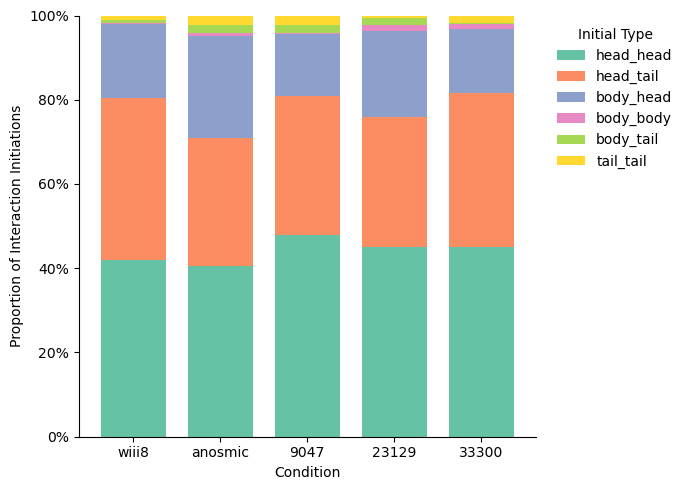

In [52]:
from matplotlib.ticker import PercentFormatter

stacked_type_order = ['head_head', 'head_tail', 'body_head', 'body_body', 'body_tail', 'tail_tail']

# Count each initiation type within each condition, then convert counts to proportions.
interaction_type_counts = (
    df.groupby(['condition', 'initial_type'])
      .size()
      .unstack(fill_value=0)
      .reindex(index=condition_order, columns=stacked_type_order, fill_value=0)
)

interaction_type_proportions = interaction_type_counts.div(
    interaction_type_counts.sum(axis=1),
    axis=0,
)

interaction_type_colors = sns.color_palette('Set2', n_colors=len(stacked_type_order))

ax = interaction_type_proportions.plot(
    kind='bar',
    stacked=True,
    color=interaction_type_colors,
    figsize=(7, 5),
    width=0.75,
)

ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylabel('Proportion of Interaction Initiations')
ax.set_xlabel('Condition')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Initial Type', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/sensory-mutants/interaction_initiation_type_proportions.pdf', format='pdf', bbox_inches='tight')
plt.show()

initial_type       comparison    U        p significance
   head_tail anosmic vs wiii8 19.5 0.023290            *
   head_tail    9047 vs wiii8 66.0 0.241145           ns
   head_tail   23129 vs wiii8 17.0 0.013983            *
   head_tail   33300 vs wiii8 67.0 0.212294           ns
   head_head anosmic vs wiii8 42.0 0.570750           ns
   head_head    9047 vs wiii8 95.0 0.000769          ***
   head_head   23129 vs wiii8 38.0 0.384673           ns
   head_head   33300 vs wiii8 67.5 0.198596           ns
   body_head anosmic vs wiii8 49.0 0.969839           ns
   body_head    9047 vs wiii8 68.5 0.173294           ns
   body_head   23129 vs wiii8 35.0 0.272856           ns
   body_head   33300 vs wiii8 53.0 0.850051           ns
   body_tail anosmic vs wiii8 15.0 0.592910           ns
   body_tail    9047 vs wiii8 13.0 0.924376           ns
   body_tail   23129 vs wiii8  7.0 0.331425           ns
   body_tail   33300 vs wiii8  0.0 0.400000           ns
   tail_tail anosmic vs wiii8  

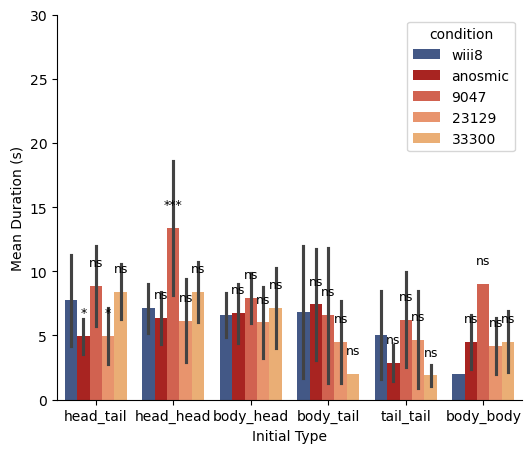

In [53]:
from scipy.stats import mannwhitneyu

duration_by_type = (
    df.groupby(['condition', 'file', 'initial_type'], as_index=False)['duration']
      .mean()
)
initial_type_order = df['initial_type'].drop_duplicates().tolist()

stats_rows = []

for initial_type in initial_type_order:
    control = duration_by_type.loc[
        (duration_by_type['condition'] == 'wiii8') &
        (duration_by_type['initial_type'] == initial_type),
        'duration'
    ]

    for condition in condition_order:
        if condition == 'wiii8':
            continue

        test_group = duration_by_type.loc[
            (duration_by_type['condition'] == condition) &
            (duration_by_type['initial_type'] == initial_type),
            'duration'
        ]

        u_stat, p_value = mannwhitneyu(test_group, control, alternative='two-sided')

        if p_value < 0.001:
            significance = '***'
        elif p_value < 0.01:
            significance = '**'
        elif p_value < 0.05:
            significance = '*'
        else:
            significance = 'ns'

        stats_rows.append({
            'initial_type': initial_type,
            'comparison': f'{condition} vs wiii8',
            'U': u_stat,
            'p': p_value,
            'significance': significance,
        })

stats_table = pd.DataFrame(stats_rows)
print(stats_table.to_string(index=False))

plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=duration_by_type,
    x='initial_type',
    order=initial_type_order,
    hue='condition',
    hue_order=condition_order,
    y='duration',
    palette=condition_colors,
    errorbar='sd',
)

y_offset = duration_by_type['duration'].max() * 0.05
for bars, condition in zip(ax.containers, condition_order):
    if condition == 'wiii8':
        continue

    for bar, initial_type in zip(bars, initial_type_order):
        row = stats_table.loc[
            (stats_table['initial_type'] == initial_type) &
            (stats_table['comparison'] == f'{condition} vs wiii8')
        ]

        if len(row) > 0:
            x = bar.get_x() + bar.get_width() / 2
            y = bar.get_height() + y_offset
            ax.text(x, y, row['significance'].iloc[0], ha='center', va='bottom', fontsize=9)

plt.ylim(0, 30)
plt.ylabel('Mean Duration (s)')
plt.xlabel('Initial Type')
sns.despine()

plt.show()

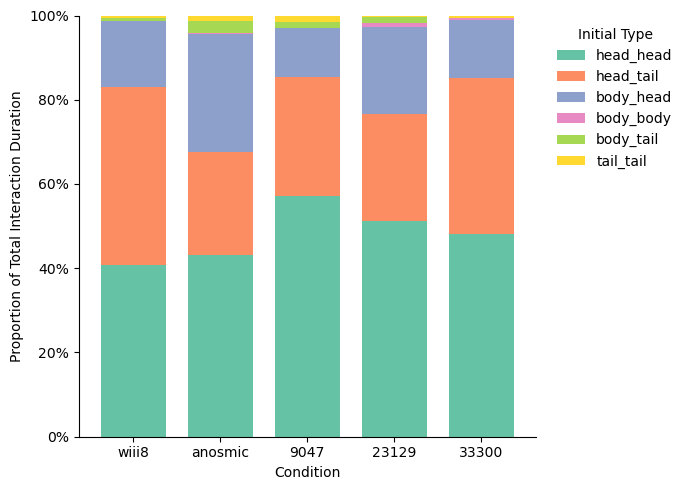

In [54]:
from matplotlib.ticker import PercentFormatter

stacked_type_order = ['head_head', 'head_tail', 'body_head', 'body_body', 'body_tail', 'tail_tail']

# Sum bout durations by initiation type, then calculate each type's share of total interaction time.
duration_type_totals = (
    df.groupby(['condition', 'initial_type'])['duration']
      .sum()
      .unstack(fill_value=0)
      .reindex(index=condition_order, columns=stacked_type_order, fill_value=0)
)

duration_type_proportions = duration_type_totals.div(
    duration_type_totals.sum(axis=1),
    axis=0,
)

duration_type_colors = sns.color_palette('Set2', n_colors=len(stacked_type_order))

ax = duration_type_proportions.plot(
    kind='bar',
    stacked=True,
    color=duration_type_colors,
    figsize=(7, 5),
    width=0.75,
)

ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylabel('Proportion of Total Interaction Duration')
ax.set_xlabel('Condition')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Initial Type', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/sensory-mutants/interaction_duration_type_proportions.pdf', format='pdf', bbox_inches='tight')
plt.show()